In [1]:
# import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# laoding data form csv
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"train dataset: {train_df.shape}")
print(f"test dataset: {test_df.shape}")

# check last few rows of data
train_df.tail(2)

train dataset: (47439, 41)
test dataset: (31626, 40)


,Id,Address,Sold Price,Summary,Type,Year built,Heating,Cooling,Parking,Lot,...,Parking features,Tax assessed value,Annual tax amount,Listed On,Listed Price,Last Sold On,Last Sold Price,City,Zip,State
47437,47437,9996 Fan Shell Ln,500000.0,Great opportunity to live in the friendly gate...,SingleFamily,2017.0,Central,Central Air,"Garage, Carport, Garage - Attached, Covered",5945.0,...,"Garage, Carport, Garage - Attached, Covered",484696.0,7627.0,2020-08-01,499888.0,2020-08-24,500000.0,Elk Grove,95757,CA
47438,47438,4552 Howard Ave,760000.0,This fantastic single story home is on a large...,SingleFamily,1948.0,NaN,NaN,Garage - Attached,8250.0,...,Garage - Attached,49671.0,1089.0,2020-11-02,748000.0,NaN,NaN,Los Alamitos,90720,CA


In [2]:
# how isnull work 
test_isnull = train_df.isnull()
test_isnull.tail(2)

,Id,Address,Sold Price,Summary,Type,Year built,Heating,Cooling,Parking,Lot,...,Parking features,Tax assessed value,Annual tax amount,Listed On,Listed Price,Last Sold On,Last Sold Price,City,Zip,State
47437,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
47438,False,False,False,False,False,False,True,True,False,False,...,False,False,False,False,False,True,True,False,False,False


In [3]:
# with sum
test_isnull_sum = train_df.isnull().sum() # by default axis = 0 
test_isnull_sum.head()

Id              0
Address         0
Sold Price      0
Summary       354
Type            0
dtype: int64

In [4]:
# check how many data is missing in dataframe
missing = train_df.isnull().sum()
missing_percent = 100 * missing / len(train_df)

missing_df = pd.DataFrame({
    '# Missing': missing,
    'Missing Rate%': missing_percent
})

missing_df = missing_df[missing_df['# Missing'] > 0].sort_values('Missing Rate%', ascending=False)
print(missing_df)


                             # Missing  Missing Rate%
Cooling features                 22223      46.845423
Cooling                          20694      43.622336
Last Sold Price                  17766      37.450199
Last Sold On                     17766      37.450199
Middle School Score              16705      35.213643
Middle School Distance           16704      35.211535
Middle School                    16704      35.211535
Laundry features                 14611      30.799553
Lot                              14181      29.893126
Appliances included              13593      28.653639
Flooring                         11569      24.387108
Full bathrooms                    7865      16.579186
Heating features                  7693      16.216615
Heating                           6852      14.443812
High School Score                 5219      11.001497
High School Distance              5001      10.541959
High School                       5000      10.539851
Elementary School Score     

In [5]:
# cooling && cooling feature
# check out what values are included in these to columns
print("Cooling values：")
print(train_df['Cooling'].value_counts().head(10))

print("\nCooling features values：")
print(train_df['Cooling features'].value_counts().head(10))

# 看看两者的重叠情况
print("\nCooling has value Cooling features missing：")
# ~train_df['Cooling'].isnull() -> !cooling is not Null && Cooling features is null
print(((~train_df['Cooling'].isnull()) & (train_df['Cooling features'].isnull())).sum())

print("\nCooling features has value Cooling missing：")
print(((train_df['Cooling'].isnull()) & (~train_df['Cooling features'].isnull())).sum())

# conclude| we could drop cooling features directly

Cooling values：
Cooling
Central Air                8875
Central AC                 6066
Central                    2756
Ceiling Fan                1137
Ceiling Fan, Central AC     901
Other                       898
Wall/Window Unit(s)         690
Multi-Zone, Central AC      478
Window / Wall Unit          342
See Remarks                 179
Name: count, dtype: int64

Cooling features values：
Cooling features
Central                12373
Central Air             7321
Other                   1019
Wall                     667
Wall/Window Unit(s)      663
Central, Solar           270
Evaporative              210
Central, Other           159
See Remarks              157
Ceiling Fan(s)           137
Name: count, dtype: int64

Cooling has value Cooling features missing：
1529

Cooling features has value Cooling missing：
0


In [6]:
# Heating vs Heating features
print("\n" + "="*60)
print("Heating vs Heating features")
print("="*60)
print(f"Heating 有值但 Heating features 缺失: {((~train_df['Heating'].isnull()) & train_df['Heating features'].isnull()).sum()}")
print(f"Heating features 有值但 Heating 缺失: {(train_df['Heating'].isnull() & (~train_df['Heating features'].isnull())).sum()}")

# Parking vs Parking features
print("\n" + "="*60)
print("Parking vs Parking features")
print("="*60)
print(f"Parking 有值但 Parking features 缺失: {((~train_df['Parking'].isnull()) & train_df['Parking features'].isnull()).sum()}")
print(f"Parking features 有值但 Parking 缺失: {(train_df['Parking'].isnull() & (~train_df['Parking features'].isnull())).sum()}")


Heating vs Heating features
Heating 有值但 Heating features 缺失: 841
Heating features 有值但 Heating 缺失: 0

Parking vs Parking features
Parking 有值但 Parking features 缺失: 3401
Parking features 有值但 Parking 缺失: 0


In [7]:
# reset dataframe

train_clean_df = train_df.copy()
test_clean_df = test_df.copy()

train_target = train_target = train_clean_df['Sold Price'].copy()

In [8]:
# for one hot , bypass rare value if < 100
def analyze_and_merge_rare_categories(train_df, test_df, columns, threshold=100, auto_merge=False):
    """
    分析并合并低频类别
    
    参数:
        auto_merge: False=只分析, True=自动合并
    """
    for col in columns:
        if col not in train_df.columns:
            print(f"⚠️ 列 '{col}' 不存在，跳过")
            continue
        
        print(f"\n{'='*60}")
        print(f"列: {col}")
        print('='*60)
        
        # 统计频率
        value_counts = train_df[col].value_counts()
        
        print(f"总类别数: {len(value_counts)}")
        print(f"< {threshold} 的类别: {(value_counts < threshold).sum()}")
        print(f">= {threshold} 的类别: {(value_counts >= threshold).sum()}")
        
        # 显示前10个
        print(f"\n频率 Top 10:")
        print(value_counts.head(10))
        
        if auto_merge:
            # 找出保留的类别
            frequent = value_counts[value_counts >= threshold].index
            
            # 替换
            train_df.loc[~train_df[col].isin(frequent), col] = 'Other'
            test_df.loc[~test_df[col].isin(frequent), col] = 'Other'
            
            print(f"\n✅ 已合并为'Other'")

# 第1步：先分析（不修改数据）
columns_to_check = ['Type', 'Heating', 'Cooling', 'Parking', 'Region', 'Flooring', 'Laundry features']
analyze_and_merge_rare_categories(train_clean_df, test_clean_df, columns_to_check, threshold=100, auto_merge=True)

# 第2步：确认后再合并
# analyze_and_merge_rare_categories(train_clean_df, test_clean_df, columns_to_check, threshold=100, auto_merge=True)


列: Type
总类别数: 158
< 100 的类别: 149
>= 100 的类别: 9

频率 Top 10:
Type
SingleFamily          31324
Condo                  8094
Townhouse              2545
Unknown                1597
MultiFamily            1292
MobileManufactured     1002
VacantLand              810
Single Family           177
Apartment               169
Residential Lot          49
Name: count, dtype: int64

✅ 已合并为'Other'

列: Heating
总类别数: 1859
< 100 的类别: 1824
>= 100 的类别: 35

频率 Top 10:
Heating
Central                     9593
Central Forced Air          5394
Central Forced Air - Gas    3528
Forced Air                  2532
Wall Furnace                1915
Other                       1464
Forced air, Gas             1332
Forced air                  1244
Central, Gas                 726
Gas                          515
Name: count, dtype: int64

✅ 已合并为'Other'

列: Cooling
总类别数: 540
< 100 的类别: 519
>= 100 的类别: 21

频率 Top 10:
Cooling
Central Air                8875
Central AC                 6066
Central                    2756
C

In [9]:
# Applicances included , convert to # of applicances split by ","
# 定义函数：统计逗号分隔的数量
def count_appliances(text):
    """
    统计逗号分隔的家电数量
    """
    if pd.isna(text):  # 如果是 NaN
        return 0
    else:
        # 按逗号分隔，统计数量
        return len(text.split(','))


# 创建新列
train_clean_df['Num_Appliances'] = train_clean_df['Appliances included'].apply(count_appliances)
test_clean_df['Num_Appliances'] = test_clean_df['Appliances included'].apply(count_appliances)
# 查看结果
print("\n✅ 转换完成！")
print("\nNum_Appliances 分布：")
print(test_clean_df['Num_Appliances'].value_counts().sort_index())

print("\n统计信息：")
print(test_clean_df['Num_Appliances'].describe())


✅ 转换完成！

Num_Appliances 分布：
Num_Appliances
0     10160
1      1837
2      2896
3      3341
4      3345
5      2760
6      2295
7      1777
8      1315
9       677
10      421
11      256
12      187
13      103
14       67
15       55
16       48
17       26
18       18
19       10
20       11
21        6
22        6
23        3
24        2
25        1
26        2
27        1
Name: count, dtype: int64

统计信息：
count    31626.000000
mean         3.239392
std          3.232173
min          0.000000
25%          0.000000
50%          3.000000
75%          5.000000
max         27.000000
Name: Num_Appliances, dtype: float64


In [10]:
## handle bedrooms
def count_bedrooms(text):
    """
    统计逗号分隔的家电数量
    """
    if pd.isna(text):  # 如果是 NaN
        return np.nan

    if isinstance(text, (int, float)):
        return text

    value_str = str(text)
    try: 
        return float(value_str)
    except:
        pass
    parts = value_str.split(',')
    closet_count = value_str.lower().count('closet')
    return len(parts) - closet_count
    


# 创建新列
train_clean_df['Bedrooms'] = train_clean_df['Bedrooms'].apply(count_bedrooms)
test_clean_df['Bedrooms'] = test_clean_df['Bedrooms'].apply(count_bedrooms)

In [11]:
# some feature might still helpful for the model and final res, handle them after baseline model
drop_features = [
    'Id', 
    'Cooling features', 
    'Heating features', 
    'Parking features', 
    'Address', 
    'Summary', 
    'Last Sold Price', 
    'Last Sold On',
    'Elementary School',
    'Middle School',
    'High School',
    'Appliances included',
    'City',
    'Zip',
    'State',
    'Sold Price',
    'Listed On',
]

# 只删除存在的列
train_clean_df = train_clean_df.drop(columns=[col for col in drop_features if col in train_clean_df.columns])
test_clean_df = test_clean_df.drop(columns=[col for col in drop_features if col in test_clean_df.columns])
print(f"✅ 已删除 {len([col for col in drop_features if col in train_df.columns])} 个特征")

print(f"剩余特征数: {train_clean_df.shape[1]}")
print(f"训练集大小: {train_clean_df.shape}")
print(f"测试集大小: {test_clean_df.shape}")


✅ 已删除 17 个特征
剩余特征数: 25
训练集大小: (47439, 25)
测试集大小: (31626, 25)


In [12]:
# ============================================
# 填充数值型特征的缺失值 + 标准化
# ============================================
from sklearn.preprocessing import StandardScaler

# 识别数值型特征
numeric_features = train_clean_df.select_dtypes(include=[np.number]).columns.tolist() # extract all field name that match the data type

print(f"\n数值型特征: {len(numeric_features)} 个")

# 第1步：用中位数填充
print("\n正在填充缺失值...")
for col in numeric_features:
    if train_clean_df[col].isnull().sum() > 0:
        median_value = train_clean_df[col].median()
        train_clean_df[col].fillna(median_value, inplace=True)
        test_clean_df[col].fillna(median_value, inplace=True)
        print(f"  - {col}: 用中位数 {median_value:.2f} 填充")

print("\n✅ 数值型特征缺失值已填充")



数值型特征: 18 个

正在填充缺失值...
  - Year built: 用中位数 1967.00 填充
  - Lot: 用中位数 6502.00 填充
  - Bedrooms: 用中位数 3.00 填充
  - Bathrooms: 用中位数 2.00 填充
  - Full bathrooms: 用中位数 2.00 填充
  - Total interior livable area: 用中位数 1566.00 填充
  - Total spaces: 用中位数 1.00 填充
  - Garage spaces: 用中位数 1.00 填充
  - Elementary School Score: 用中位数 6.00 填充
  - Elementary School Distance: 用中位数 0.50 填充
  - Middle School Score: 用中位数 5.00 填充
  - Middle School Distance: 用中位数 1.00 填充
  - High School Score: 用中位数 6.00 填充
  - High School Distance: 用中位数 1.30 填充
  - Tax assessed value: 用中位数 547524.00 填充
  - Annual tax amount: 用中位数 7129.00 填充

✅ 数值型特征缺失值已填充


In [13]:
 train_clean_df.head(2)

,Type,Year built,Heating,Cooling,Parking,Lot,Bedrooms,Bathrooms,Full bathrooms,Total interior livable area,...,Middle School Score,Middle School Distance,High School Score,High School Distance,Flooring,Laundry features,Tax assessed value,Annual tax amount,Listed Price,Num_Appliances
0,SingleFamily,1969.0,"Heating - 2+ Zones, Central Forced Air - Gas",Other,"Garage, Garage - Attached, Covered",1.0,3.0,0.0,2.0,1.0,...,5.0,1.0,8.0,1.3,"Tile, Hardwood, Carpet","Washer / Dryer, Inside, In Utility Room",886486.0,12580.0,4198000.0,6
1,SingleFamily,1926.0,Other,Other,Other,4047.0,3.0,2.0,2.0,872.0,...,2.0,1.1,2.0,1.3,Other,Inside,505000.0,6253.0,525000.0,0


In [14]:
# handle object type data with one hot
# ============================================
# One-Hot 编码所有类别特征
# ============================================

# 1. 识别类别特征
categorical_features = train_clean_df.select_dtypes(include=['object']).columns.tolist()
print(f"类别特征: {len(categorical_features)} 个")
print(categorical_features)

# 2. 填充缺失值（用 'Unknown'）
for col in categorical_features:
    train_clean_df[col].fillna('Unknown', inplace=True)
    test_clean_df[col].fillna('Unknown', inplace=True)

print("\n✅ 类别特征缺失值已填充")

# 3. One-Hot 编码（关键：训练集和测试集一起处理）
# 先合并
# this could be in used at very first begining for convient useage
train_clean_df['dataset_type'] = 'train'
test_clean_df['dataset_type'] = 'test'

combined = pd.concat([train_clean_df, test_clean_df], axis=0, ignore_index=True)

# One-Hot 编码
combined_encoded = pd.get_dummies(combined, columns=categorical_features, drop_first=False)

# 分离回训练集和测试集
train_clean_df = combined_encoded[combined_encoded['dataset_type'] == 'train'].drop(columns=['dataset_type']).reset_index(drop=True)
test_clean_df = combined_encoded[combined_encoded['dataset_type'] == 'test'].drop(columns=['dataset_type']).reset_index(drop=True)

print("\n✅ One-Hot 编码完成")
print(f"训练集: {train_clean_df.shape}")
print(f"测试集: {test_clean_df.shape}")

类别特征: 7 个
['Type', 'Heating', 'Cooling', 'Parking', 'Region', 'Flooring', 'Laundry features']

✅ 类别特征缺失值已填充

✅ One-Hot 编码完成
训练集: (47439, 266)
测试集: (31626, 266)


In [15]:
# 添加一个最终检查
print("\n" + "="*60)
print("最终数据检查")
print("="*60)
print(f"训练集: {train_clean_df.shape}")
print(f"测试集: {test_clean_df.shape}")
print(f"目标变量: {train_target.shape}")

# 检查是否还有缺失值
print(f"\n训练集缺失值: {train_clean_df.isnull().sum().sum()}")
print(f"测试集缺失值: {test_clean_df.isnull().sum().sum()}")

# 检查数据类型
print(f"\n所有特征都是数值型: {len(train_clean_df.select_dtypes(include='object').columns) == 0}")


最终数据检查
训练集: (47439, 266)
测试集: (31626, 266)
目标变量: (47439,)

训练集缺失值: 0
测试集缺失值: 0

所有特征都是数值型: True


处理目标变量
原始房价范围: $100,500 - $90,000,000
对数房价范围: 11.51792296 - 18.31532024


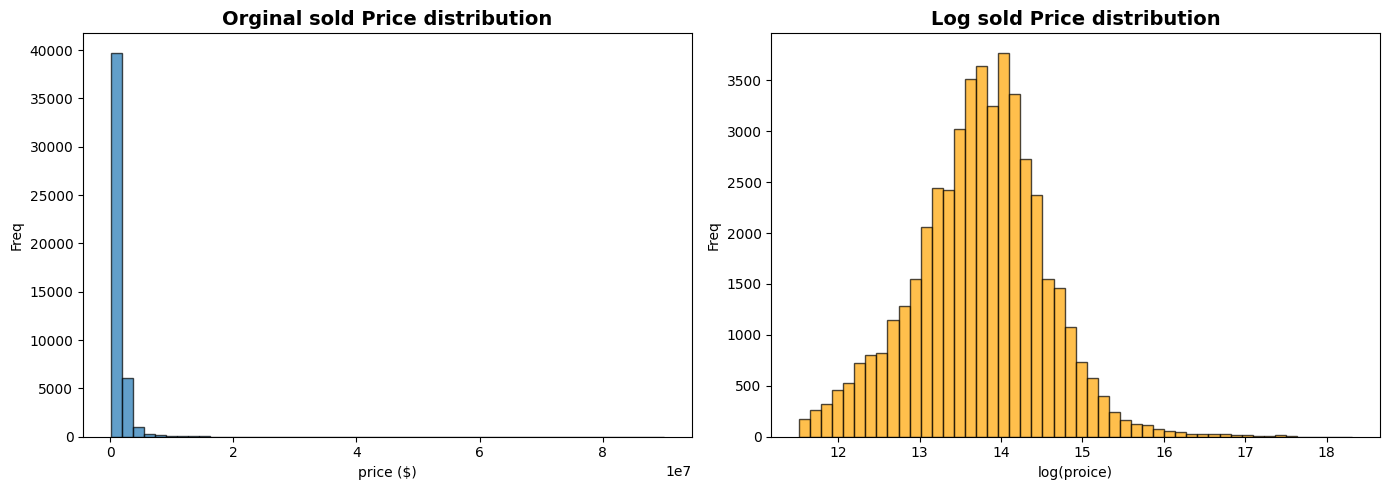


✅ 目标变量已转换为对数尺度


In [16]:
# ============================================
# 第1步：处理目标变量（取对数）
# ============================================

print("="*60)
print("处理目标变量")
print("="*60)

# 已有数据（从你的清洗步骤得到）
# train_target: 原始房价
# train_clean_df: 清洗后的特征
# test_clean_df: 测试集特征

# 1.1 对目标变量取对数
train_target_log = np.log1p(train_target)

print(f"原始房价范围: ${train_target.min():,.0f} - ${train_target.max():,.0f}")
print(f"对数房价范围: {train_target_log.min():.8f} - {train_target_log.max():.8f}")


# 1.2 可视化对比（可选）
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_target, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Orginal sold Price distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('price ($)')
axes[0].set_ylabel('Freq')

axes[1].hist(train_target_log, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Log sold Price distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(proice)')
axes[1].set_ylabel('Freq')

plt.tight_layout()
plt.show()

print("\n✅ 目标变量已转换为对数尺度")

In [17]:
# ============================================
# 第2步：划分数据
# ============================================

from sklearn.model_selection import train_test_split

# 划分：80% 训练，20% 验证
X_train, X_val, y_train, y_val = train_test_split(
    train_clean_df,      # 特征
    train_target_log,    # 对数目标变量（重要！）
    test_size=0.2,
    random_state=42
)

print("\n" + "="*60)
print("数据划分")
print("="*60)
print(f"训练集: {X_train.shape}")
print(f"验证集: {X_val.shape}")
print(f"测试集: {test_clean_df.shape}")

# 2. 再标准化（关键：只在训练集上fit）
print("\n开始标准化...")
scaler = StandardScaler()

# 只在训练集上学习统计信息
scaler.fit(X_train[numeric_features])

# 转换所有数据集
X_train[numeric_features] = scaler.transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
test_clean_df[numeric_features] = scaler.transform(test_clean_df[numeric_features])

print("✅ 标准化完成")
print(f"训练集均值: {X_train[numeric_features].mean().mean():.6f}")
print(f"验证集均值: {X_val[numeric_features].mean().mean():.6f}")


数据划分
训练集: (37951, 266)
验证集: (9488, 266)
测试集: (31626, 266)

开始标准化...
✅ 标准化完成
训练集均值: -0.000000
验证集均值: -0.002918


In [18]:
test_clean_df.head(2)

,Year built,Lot,Bedrooms,Bathrooms,Full bathrooms,Total interior livable area,Total spaces,Garage spaces,Elementary School Score,Elementary School Distance,...,Laundry features_See Remarks,Laundry features_Stackable,"Laundry features_Upper Floor, Washer / Dryer","Laundry features_Upper Floor, Washer / Dryer, Inside",Laundry features_Washer / Dryer,"Laundry features_Washer / Dryer, In Utility Room","Laundry features_Washer / Dryer, Inside","Laundry features_Washer / Dryer, Inside, Electricity Hookup (220V)","Laundry features_Washer / Dryer, Inside, In Utility Room","Laundry features_cabinets, Inside Room"
0,0.431031,-0.015485,-0.543292,1.448862,1.038554,-0.005307,0.279782,0.288910,1.128381,-0.262550,...,False,True,False,False,False,False,False,False,False,False
1,-0.222246,-0.014643,0.194347,-0.284392,-0.089015,-0.005250,0.050657,0.058913,0.123885,-0.351599,...,False,False,False,False,False,False,False,False,False,False


In [19]:
X_train.head(2)

,Year built,Lot,Bedrooms,Bathrooms,Full bathrooms,Total interior livable area,Total spaces,Garage spaces,Elementary School Score,Elementary School Distance,...,Laundry features_See Remarks,Laundry features_Stackable,"Laundry features_Upper Floor, Washer / Dryer","Laundry features_Upper Floor, Washer / Dryer, Inside",Laundry features_Washer / Dryer,"Laundry features_Washer / Dryer, In Utility Room","Laundry features_Washer / Dryer, Inside","Laundry features_Washer / Dryer, Inside, Electricity Hookup (220V)","Laundry features_Washer / Dryer, Inside, In Utility Room","Laundry features_cabinets, Inside Room"
36474,-0.290295,-0.014969,-0.543292,-1.151019,-1.216584,-0.005763,-0.063906,-0.056086,1.128381,-0.351599,...,False,False,False,False,False,False,False,False,False,False
12313,0.118002,-0.014643,0.931986,0.582235,-0.089015,-0.004088,0.050657,0.058913,-0.378364,-0.218026,...,False,False,False,False,False,False,False,False,False,False


In [20]:
import torch.nn as nn
import torch            
import torch.optim as optim    

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            # 第1层：更大
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.05),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            
            # 第2层
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.03),
            
            # 输出层
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        model_outputs = self.model(x)
        model_outputs = torch.sigmoid(model_outputs) * 10 + 10  # 限制输出范围
        return model_outputs

# 初始化新模型
input_dim = X_train.shape[1]
model = MLP(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print("✅ 模型创建完成")
print(f"参数量: {sum(p.numel() for p in model.parameters()):,}")

✅ 模型创建完成
参数量: 286,209


In [21]:
# ============================================
# Step 2: 训练函数
# ============================================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for features, targets in loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)
            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(targets.cpu().numpy().flatten())
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    # 计算对数空间的loss
    log_loss = np.mean((predictions - actuals)**2)
    
    # 转回原始空间计算RMSE
    predictions_original = np.expm1(predictions)
    actuals_original = np.expm1(actuals)
    rmse = np.sqrt(np.mean((predictions_original - actuals_original)**2))
    mae = np.mean(np.abs(predictions_original - actuals_original))
    
    return log_loss, rmse, mae

print("✅ 训练函数定义完成")



## ======= RMSE [Root Mean Squared Error] VS. MAE [Mean Absolute Error] ========


✅ 训练函数定义完成


In [22]:
# ============================================
# 创建 Dataset 和 DataLoader
# ============================================
from torch.utils.data import Dataset, DataLoader

class HousePriceDataset(Dataset):
    def __init__(self, features, targets):
        # 转为numpy array并强制转换为float32
        if isinstance(features, pd.DataFrame):
            features = features.astype(np.float32).values
        else:
            features = np.array(features, dtype=np.float32)
            
        if isinstance(targets, pd.Series):
            targets = targets.astype(np.float32).values
        else:
            targets = np.array(targets, dtype=np.float32)
        
        # 转为Tensor
        self.features = torch.from_numpy(features)
        self.targets = torch.from_numpy(targets).reshape(-1, 1)
    
    def __len__(self):
        return len(self.targets)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

print("✅ 修复版 Dataset 类定义完成")
# 创建 Dataset
train_dataset = HousePriceDataset(X_train, y_train)
val_dataset = HousePriceDataset(X_val, y_val)

# 创建 DataLoader
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("✅ DataLoader 创建成功")
print(f"训练集 batches: {len(train_loader)}")
print(f"验证集 batches: {len(val_loader)}")
print(f"Batch size: {batch_size}")

# 测试一下
for X_batch, y_batch in train_loader:
    print(f"\n测试第一个 batch:")
    print(f"  X shape: {X_batch.shape}")
    print(f"  y shape: {y_batch.shape}")
    break

✅ 修复版 Dataset 类定义完成
✅ DataLoader 创建成功
训练集 batches: 149
验证集 batches: 38
Batch size: 256

测试第一个 batch:
  X shape: torch.Size([256, 266])
  y shape: torch.Size([256, 1])


In [23]:
# ============================================
# Step 3: 训练循环
# ============================================
print("\n" + "="*60)
print("开始训练")
print("="*60)

num_epochs = 200
best_val_loss = float('inf')
patience = 15
patience_counter = 0

for epoch in range(num_epochs):
    # 训练
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # 验证
    val_loss, val_rmse, val_mae = evaluate(model, val_loader, device)
    
    # 每10轮打印
    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val RMSE: ${val_rmse:,.0f} | "
              f"Val MAE: ${val_mae:,.0f}")
    
    # 早停
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print("best model so far saved: " + str(best_val_loss))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏹ 早停于 epoch {epoch+1}")
            break

# 加载最佳模型
model.load_state_dict(torch.load('best_model.pth'))
print("\n✅ 训练完成！")


开始训练
Epoch [  1/200] | Train Loss: 0.1960 | Val Loss: 0.0860 | Val RMSE: $1,218,679 | Val MAE: $274,722
best model so far saved: 0.08599237
Epoch [  2/200] | Train Loss: 0.1075 | Val Loss: 0.0851 | Val RMSE: $1,908,133 | Val MAE: $288,732
best model so far saved: 0.08505202
Epoch [  3/200] | Train Loss: 0.0848 | Val Loss: 0.0688 | Val RMSE: $1,080,403 | Val MAE: $208,437
best model so far saved: 0.06884247
Epoch [  4/200] | Train Loss: 0.0743 | Val Loss: 0.0982 | Val RMSE: $1,013,929 | Val MAE: $229,495
Epoch [  5/200] | Train Loss: 0.0696 | Val Loss: 0.0626 | Val RMSE: $1,063,796 | Val MAE: $207,785
best model so far saved: 0.06260592
Epoch [  6/200] | Train Loss: 0.0651 | Val Loss: 0.0764 | Val RMSE: $941,038 | Val MAE: $205,753
Epoch [  7/200] | Train Loss: 0.0587 | Val Loss: 0.0769 | Val RMSE: $948,175 | Val MAE: $222,874
Epoch [  8/200] | Train Loss: 0.0565 | Val Loss: 0.1025 | Val RMSE: $933,490 | Val MAE: $235,046
Epoch [  9/200] | Train Loss: 0.0533 | Val Loss: 0.0745 | Val RM

In [24]:
# ============================================
# Step 1: 准备测试集
# ============================================
print("="*60)
print("准备测试集")
print("="*60)

# 检查测试集
print(f"测试集形状: {test_clean_df.shape}")
print(f"测试集缺失值: {test_clean_df.isnull().sum().sum()}")

# 确保类型正确
test_clean_df_fixed = test_clean_df.astype(np.float32)

print("✅ 测试集准备完成")

准备测试集
测试集形状: (31626, 266)
测试集缺失值: 0
✅ 测试集准备完成


In [25]:
# ============================================
# Step 2: 预测测试集
# ============================================
print("\n" + "="*60)
print("预测测试集")
print("="*60)

# 转换为Tensor
test_features = torch.FloatTensor(test_clean_df_fixed.values)

# 创建DataLoader（方便批量预测）
test_dataset_final = torch.utils.data.TensorDataset(test_features)
test_loader_final = DataLoader(test_dataset_final, batch_size=256, shuffle=False)

# 预测
model.eval()
test_predictions = []

with torch.no_grad():
    for batch in test_loader_final:
        features = batch[0].to(device)
        outputs = model(features)
        test_predictions.extend(outputs.cpu().numpy().flatten())

test_predictions = np.array(test_predictions)

print(f"✅ 预测完成，共 {len(test_predictions)} 个样本")
print(f"预测值范围（对数空间）: [{test_predictions.min():.2f}, {test_predictions.max():.2f}]")


预测测试集
✅ 预测完成，共 31626 个样本
预测值范围（对数空间）: [10.20, 18.47]


In [26]:
# ============================================
# 完整提交文件生成流程（修复版）
# ============================================
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader

print("="*60)
print("🚀 生成Kaggle提交文件")
print("="*60)

# 1. 准备测试集
print("\n[1/5] 准备测试集...")
test_clean_df_fixed = test_clean_df.astype(np.float32)
test_features = torch.FloatTensor(test_clean_df_fixed.values)
test_dataset_final = torch.utils.data.TensorDataset(test_features)
test_loader_final = DataLoader(test_dataset_final, batch_size=256, shuffle=False)

# 2. 预测
print("[2/5] 预测测试集...")
model.eval()
test_predictions = []
with torch.no_grad():
    for batch in test_loader_final:
        features = batch[0].to(device)
        outputs = model(features)
        test_predictions.extend(outputs.cpu().numpy().flatten())
test_predictions = np.array(test_predictions)

# 3. 转换
print("[3/5] 转换为原始房价...")
test_predictions_clipped = np.clip(test_predictions, 10.0, 20.0)
test_predictions_original = np.expm1(test_predictions_clipped)

# 4. 创建提交文件
print("[4/5] 创建提交文件...")
test_df_original = pd.read_csv('data/test.csv')
submission = pd.DataFrame({
    'Id': test_df_original['Id'],
    'Sold Price': test_predictions_original
})
submission.to_csv('submission.csv', index=False)

# 5. 验证
print("[5/5] 验证...")
print(f"\n✅ 完成！")
print(f"   文件: submission.csv")
print(f"   行数: {len(submission):,}")
print(f"   预测范围: ${submission['Sold Price'].min():,.0f} - ${submission['Sold Price'].max():,.0f}")
print(f"   平均预测: ${submission['Sold Price'].mean():,.0f}")
print(f"   中位数预测: ${np.median(submission['Sold Price']):,.0f}")  # ← 修复这里
print("\n🎉 可以上传到Kaggle了！")
print("="*60)

# 显示前10行
print("\n提交文件预览:")
print(submission.head(10))

🚀 生成Kaggle提交文件

[1/5] 准备测试集...
[2/5] 预测测试集...
[3/5] 转换为原始房价...
[4/5] 创建提交文件...
[5/5] 验证...

✅ 完成！
   文件: submission.csv
   行数: 31,626
   预测范围: $26,988 - $105,361,112
   平均预测: $865,798
   中位数预测: $611,475

🎉 可以上传到Kaggle了！

提交文件预览:
      Id    Sold Price
0  47439  8.338126e+05
1  47440  5.252506e+05
2  47441  8.459569e+05
3  47442  8.258663e+05
4  47443  1.052784e+06
5  47444  7.987101e+05
6  47445  1.627296e+06
7  47446  3.741475e+05
8  47447  1.952281e+06
9  47448  4.659981e+05


In [ ]:
# ============================================
# Baseline: 直接用 Listed Price 预测
# ============================================
print("="*60)
print("🎯 Baseline: 直接用 Listed Price")
print("="*60)

# 检查训练集
train_df_original = pd.read_csv('data/train.csv')
test_df_original = pd.read_csv('data/test.csv')

print(f"\nListed Price 缺失情况:")
print(f"训练集: {train_df_original['Listed Price'].isnull().sum()} 个缺失")
print(f"测试集: {test_df_original['Listed Price'].isnull().sum()} 个缺失")

# 创建baseline提交
baseline_submission = pd.DataFrame({
    'Id': test_df_original['Id'],
    'Sold Price': test_df_original['Listed Price']
})

# 处理缺失值（用中位数）
median_listed = train_df_original['Listed Price'].median()
baseline_submission['Sold Price'].fillna(median_listed, inplace=True)

# 保存
baseline_submission.to_csv('baseline_submission.csv', index=False)

print(f"\n✅ Baseline 提交文件已保存")
print(f"   文件: baseline_submission.csv")
print(f"   行数: {len(baseline_submission)}")
print(f"   预测范围: ${baseline_submission['Sold Price'].min():,.0f} - ${baseline_submission['Sold Price'].max():,.0f}")

# 在验证集上评估baseline
train_with_split = train_df_original.iloc[:len(y_train)]
val_with_split = train_df_original.iloc[len(y_train):len(y_train)+len(y_val)]

# 重新划分（为了对应）
from sklearn.model_selection import train_test_split
train_idx, val_idx = train_test_split(
    range(len(train_df_original)), 
    test_size=0.2, 
    random_state=42
)

# 验证集的实际价格和baseline预测
val_actual = train_df_original.iloc[val_idx]['Sold Price'].values
val_baseline_pred = train_df_original.iloc[val_idx]['Listed Price'].values

# 处理缺失值
val_baseline_pred = pd.Series(val_baseline_pred).fillna(median_listed).values

# 计算指标
baseline_rmse = np.sqrt(np.mean((val_actual - val_baseline_pred)**2))
baseline_mae = np.mean(np.abs(val_actual - val_baseline_pred))
baseline_mape = np.mean(np.abs((val_actual - val_baseline_pred) / val_actual)) * 100

print(f"\n📊 Baseline 在验证集上的表现:")
print(f"   RMSE: ${baseline_rmse:,.0f}")
print(f"   MAE:  ${baseline_mae:,.0f}")
print(f"   MAPE: {baseline_mape:.2f}%")
print("="*60)

In [27]:
# TODO: same approach todo with AutoGluon see how it goes.